# Working with complicated dataset

Your name: Zaki Sheikh

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [39]:
### Your code here . . .
import pandas as pd

url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"

fields_line = "# Fields: query acc.ver, subject acc.ver, % identity, alignment length, mismatches, gap opens, q. start, q. end, s. start, s. end, evalue, bit score, % positives, bonds, publications,"
fields = [field.strip() for field in fields_line.split(":")[1].split(",")]

# Read the CSV with proper handling of metadata lines
df = pd.read_csv(
    url,
    comment="#",           # Ignore lines starting with '#'
    header=None,           # No header row in the data
    names=fields,          # Use predefined column names
    skip_blank_lines=True,
    engine="python",       # Python engine for flexible parsing
    quotechar='"',         # Handle quoted values
    skiprows=1             # Skip metadata lines
)

# Clean data
df = df.drop(columns=["query acc.ver"])                                  # Drop unnecessary column
df = df.set_index("subject acc.ver")                                     # Set index

# Display the first 5 rows
print(df.head())



                 % identity  alignment length  mismatches  gap opens  \
subject acc.ver                                                        
NP_904328.1         100.000               318           0          0   
AGK29621.1           99.686               318           1          0   
YP_220563.1          99.686               318           1          0   
ACM24502.1           99.686               318           1          0   
AHG32084.1           99.371               318           2          0   

                 q. start  q. end  s. start  s. end  evalue  bit score  \
subject acc.ver                                                          
NP_904328.1             1     318         1     318       0        629   
AGK29621.1              1     318         1     318       0        629   
YP_220563.1             1     318         1     318       0        627   
ACM24502.1              1     318         1     318       0        627   
AHG32084.1              1     318         1     318

### Question 2
What is the average number of publications?

In [42]:
### Your code here . . .
# Convert 'publications' to numeric, coercing invalid entries to NaN
df["publications"] = pd.to_numeric(df["publications"], errors="coerce")

average_publications = df["publications"].mean()

print(f"The average number of publications is: {average_publications}")


The average number of publications is: 26.989690721649485


### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [47]:
### Your code here . . .
# Ensure the 'bonds' column is treated as strings before replacing commas
df["bonds"] = df["bonds"].astype(str).str.replace(",", "")

# Convert 'bonds' column to numeric, coercing invalid entries to NaN
df["bonds"] = pd.to_numeric(df["bonds"], errors="coerce")

# Filter the DataFrame for rows where 'bonds' > 15000
high_bonds_subjects = df[df["bonds"] > 15000].index.tolist()

# Display the subjects
print(high_bonds_subjects)


[]


### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

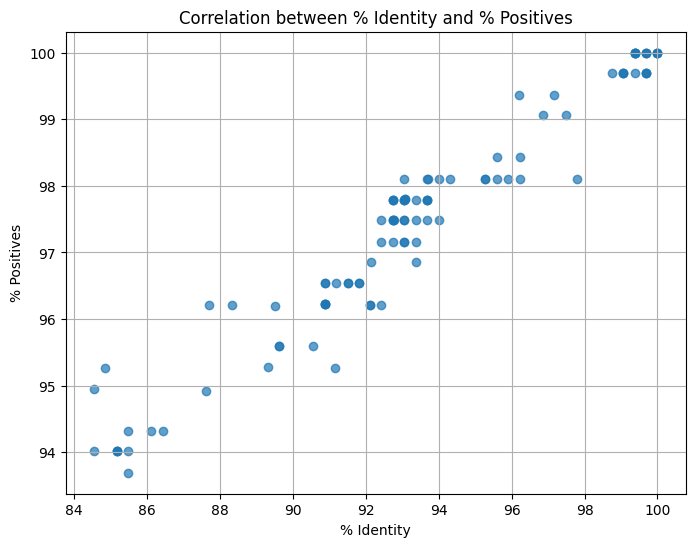

In [48]:
### Your code here . . .
import matplotlib.pyplot as plt

# Ensure the columns are numeric
df["% identity"] = pd.to_numeric(df["% identity"], errors="coerce")
df["% positives"] = pd.to_numeric(df["% positives"], errors="coerce")

# Drop rows with NaN values in the relevant columns
df_cleaned = df.dropna(subset=["% identity", "% positives"])

# Plot the correlation
plt.figure(figsize=(8, 6))
plt.scatter(df_cleaned["% identity"], df_cleaned["% positives"], alpha=0.7)
plt.title("Correlation between % Identity and % Positives")
plt.xlabel("% Identity")
plt.ylabel("% Positives")
plt.grid(True)
plt.show()


### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [50]:
### Your code here . . .
# Load the protein source dataframe
url_protein = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv"
df_protein = pd.read_csv(url_protein)

# Merge the two dataframes based on subject acc.ver and Protein
df_merged = pd.merge(
    df,
    df_protein,
    how="left",
    left_on="subject acc.ver",
    right_on="Protein"
)

# Drop the extra 'Protein' column (if desired)
df_merged = df_merged.drop(columns=["Protein"])

# Display the merged dataframe
print(df_merged.head())

   % identity  alignment length  mismatches  gap opens  q. start  q. end  \
0     100.000               318           0          0         1     318   
1      99.686               318           1          0         1     318   
2      99.686               318           1          0         1     318   
3      99.686               318           1          0         1     318   
4      99.371               318           2          0         1     318   

   s. start  s. end  evalue  bit score  % positives  bonds  publications       \
0         1     318       0        629       100.00    NaN           9.0  NaN   
1         1     318       0        629       100.00    NaN          47.0  NaN   
2         1     318       0        627       100.00    NaN          13.0  NaN   
3         1     318       0        627        99.69    NaN          41.0  NaN   
4         1     318       0        627       100.00    NaN           3.0  NaN   

   Unnamed: 0   Source  
0         0.0   RefSeq  
1     